## Decision Tree (CART) Classifier

### 1. Import Libraries

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import joblib

### 2. Create Dataset

In [ ]:
# ==========================================
# 1. TRAINING DATASET
# ==========================================
# Features: [Outlook, Temperature]
# Outlook Encoding:
# 0 = Rainy
# 1 = Overcast
# 2 = Sunny

X_train = np.array([
    [2, 85],  # Sunny, Hot
    [2, 80],  # Sunny, Hot
    [1, 83],  # Overcast, Hot
    [0, 70],  # Rainy, Mild
    [0, 68],  # Rainy, Cool
    [0, 65],  # Rainy, Cool
    [1, 64],  # Overcast, Cool
    [2, 72],  # Sunny, Mild
    [2, 69],  # Sunny, Cool
    [0, 75]   # Rainy, Mild
])

# Labels:
# 0 = Don't Play
# 1 = Play
y_train = np.array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1])

### 3. Test Dataset

In [ ]:
# ==========================================
# 2. TEST DATA
# ==========================================

X_test = np.array([
    [1, 78],  # Overcast, Mild
    [2, 84]   # Sunny, Hot
])

### 4. Train Decision Tree Model

In [ ]:
# ==========================================
# 3. MODEL TRAINING (Decision Tree - Gini)
# ==========================================

clf = DecisionTreeClassifier(
    criterion='gini',   # impurity measure
    max_depth=3,        # limit tree depth (avoid overfitting)
    random_state=42     # reproducibility
)

# Train the model
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

### 5. Make Predictions

In [ ]:
# ==========================================
# 4. MAKE PREDICTIONS
# ==========================================

predictions = clf.predict(X_test)

print("--- Decision Tree Predictions (Gini) ---\n")

for i, sample in enumerate(X_test):

    # Convert numeric outlook to readable label
    weather = ["Rainy", "Overcast", "Sunny"][sample[0]]
    temp = sample[1]

    # Convert prediction to human-readable result
    result = "Play" if predictions[i] == 1 else "Don't Play"

    print(f"Test {i+1} ({weather}, {temp}) => Predicted: {result}")

--- Decision Tree Predictions (Gini) ---

Test 1 (Overcast, 78) => Predicted: Play
Test 2 (Sunny, 84) => Predicted: Don't Play


### 6. Visualize Decision Tree

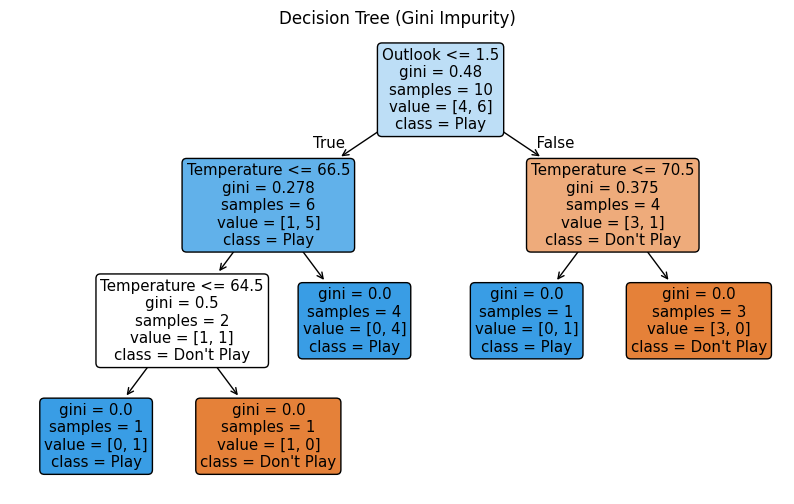

In [ ]:
# ==========================================
# 5. VISUALIZE DECISION TREE
# ==========================================

plt.figure(figsize=(10, 6))

plot_tree(
    clf,
    feature_names=['Outlook', 'Temperature'],  # feature names
    class_names=["Don't Play", "Play"],        # class labels
    filled=True,                                # color fill
    rounded=True                                # rounded boxes
)

plt.title("Decision Tree (Gini Impurity)")
plt.show()

### 7. Save Decision Tree Visualization

In [ ]:

# Save as high-quality image
plt.savefig(
    "decision_tree_visualization.png",  # file name
    dpi=300,                            # high resolution
    bbox_inches='tight'                # remove extra white space
)

print("Decision tree visualization saved as 'decision_tree_visualization.png'")

Decision tree visualization saved as 'decision_tree_visualization.png'


<Figure size 640x480 with 0 Axes>

### 8. Save Trained Model

In [ ]:
# ==========================================
# 7. SAVE TRAINED MODEL
# ==========================================

joblib.dump(clf, "decision_tree_model.pkl")

print("Model saved as 'decision_tree_model.pkl'")

Model saved as 'decision_tree_model.pkl'


### 9. Evaluate Model Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

# Make predictions on the training data
y_train_pred = clf.predict(X_train)

# Calculate the accuracy
accuracy = accuracy_score(y_train, y_train_pred)

print(f"Model Accuracy on Training Data: {accuracy:.2f}")

Model Accuracy on Training Data: 1.00


## Tasks:

*   **1. Experiment with `max_depth` Settings**
    *   Vary the `max_depth` parameter in the `DecisionTreeClassifier` (e.g., from 1 to 10) to observe its impact on model performance.
    *   Analyze the trade-off between bias and variance for different `max_depth` values.

*   **2. Implement Alternative Impurity Metrics**
    *   Evaluate the model using alternative impurity metrics such as `entropy` or `log_loss` instead of `gini` for the `criterion` parameter.
    *   Compare the resulting tree structure and prediction accuracy with the current `gini`-based model.

*   **3. Explore Different Train-Test Split Ratios**
    *   Investigate the effect of varying train-test split ratios (e.g., 70:30, 60:40) on model training and generalization performance.
    *   Assess the stability of the model's performance across different splits.

### Create a Results Table
    1.  Develop a structured table to record and compare the outcomes of the experiments conducted in Tasks 1-3.
    2.  Include key metrics such as accuracy, precision, recall, F1-score, and relevant model parameters (`max_depth`, `criterion`, split ratio) for each experiment.
